In [1]:
#234567890#234567890#234567890#234567890#234567890#234567890#234567890#23456789
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

In [2]:
IMG = f'../../../img'

In [3]:
x = np.uint8([250])
y = np.uint8([10])
x + y  # 260 % 256

array([4], dtype=uint8)

In [4]:
cv.add(x, y)

array([[260.],
       [  0.],
       [  0.],
       [  0.]])

### Image blending

In [6]:
img1 = cv.imread(f'{IMG}/birds.jpg')
img1 = cv.cvtColor(img1, cv.COLOR_RGB2BGR)
img1 = img1[:396, :512, :]
img1.shape

(396, 512, 3)

In [7]:
img2 = cv.imread(f'{IMG}/baboon.png')
img2 = cv.cvtColor(img2, cv.COLOR_RGB2BGR)
img2 = img2[:396, :512, :]
img2.shape

(396, 512, 3)

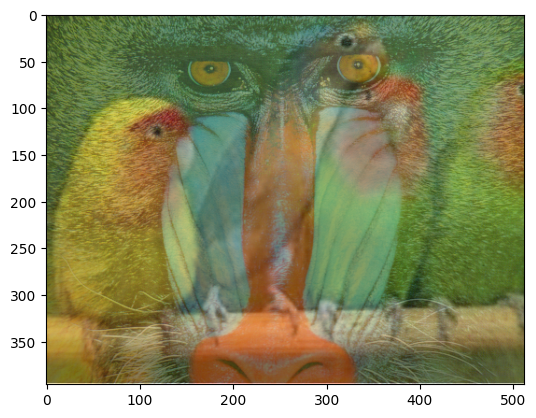

In [8]:
dst = cv.addWeighted(img1, 0.6, img2, 0.4, 0)
plt.imshow(dst);

### Bitwise ops

In [9]:
rows, cols, channels = img2.shape
roi = img1[:rows, : cols]

In [21]:
img2grey = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)
ret, mask = cv.threshold(img2grey, 75, 125, cv.THRESH_BINARY)
mask_inv = cv.bitwise_not(mask)

In [22]:
img1_bg = cv.bitwise_and(roi, roi, mask=mask_inv)
img2_fg = cv.bitwise_and(img2, img2, mask=mask)
dst = cv.add(img1_bg, img2_fg)
img1[:rows, :cols] = dst

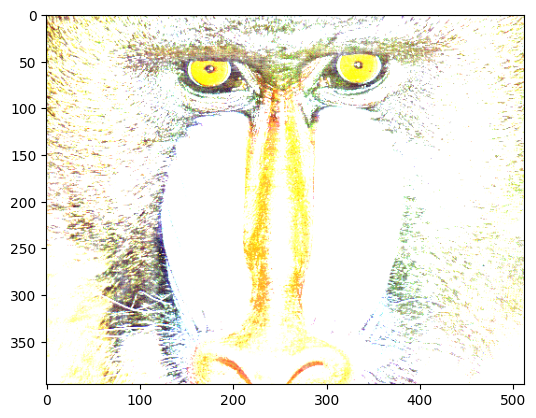

In [23]:
plt.imshow(img1);